In [1]:
from google.colab import drive
drive.mount('/content/drive')

import shutil
from pathlib import Path

DRIVE_SIH = Path('/content/drive/MyDrive/SIH_data')  # adjust if your Drive path differs
LOCAL_SIH = Path('/content/SIH_data')

assert DRIVE_SIH.exists(), f"Not found: {DRIVE_SIH} — check your Drive folder name/path"
if not LOCAL_SIH.exists():
    shutil.copytree(DRIVE_SIH, LOCAL_SIH)
print(list(LOCAL_SIH.glob('*.csv')))

Mounted at /content/drive
[PosixPath('/content/SIH_data/groundtruth_validation.csv'), PosixPath('/content/SIH_data/telemetry_validation.csv'), PosixPath('/content/SIH_data/groundtruth_train.csv'), PosixPath('/content/SIH_data/telemetry_train.csv')]


In [2]:
import os
for d in ['ml', 'ml/features', 'ml/training', 'ml/training/autoencoder']:
    os.makedirs(d, exist_ok=True)
    open(f'{d}/__init__.py', 'a').close()

In [3]:
%%writefile ml/features/feature_engineering.py
import json
from functools import lru_cache
from pathlib import Path
from typing import Any

import joblib
import numpy as np
import pandas as pd

_DEFAULT_DIGITAL_TWIN_DIR = Path(__file__).resolve().parents[1] / "artifacts" / "digital_twin" / "v1"
_CONDITION_FEATURES = ["rpm", "throttle", "altitude", "ambient_temperature", "air_density"]
_GATED_OUT_STATES = {"STARTING", "SHUTDOWN", "THROTTLE_TRANSIENT"}


@lru_cache(maxsize=4)
def _load_digital_twin_models(artifacts_dir: str) -> dict[str, Any]:
    path = Path(artifacts_dir)
    metadata = json.loads((path / "metadata.json").read_text())
    return {target: joblib.load(path / f"{target}.joblib") for target in metadata["target_channels"]}


def physics_residuals(frame: pd.DataFrame, artifacts_dir=_DEFAULT_DIGITAL_TWIN_DIR) -> pd.DataFrame:
    models = _load_digital_twin_models(str(artifacts_dir))
    gated = frame["engine_state"].isin(_GATED_OUT_STATES)
    condition = frame[_CONDITION_FEATURES]

    residuals = {}
    for target, model in models.items():
        if target not in frame.columns:
            continue
        expected = pd.Series(model.predict(condition), index=frame.index)
        residual = frame[target] - expected
        residual[gated] = np.nan
        residuals[f"{target}_residual"] = residual

    return pd.DataFrame(residuals, index=frame.index)

Writing ml/features/feature_engineering.py


In [4]:
%%writefile ml/features/fit_digital_twin.py
import argparse
import json
from pathlib import Path

import joblib
import pandas as pd
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import train_test_split

CONDITION_FEATURES = ["rpm", "throttle", "altitude", "ambient_temperature", "air_density"]

TARGET_CHANNELS = [
    "torque", "power", "cht_c1", "cht_c2", "cht_c3", "cht_c4",
    "egt_c1", "egt_c2", "egt_c3", "egt_c4", "oil_pressure", "oil_temperature",
    "fuel_flow", "rail_pressure", "injection_timing", "boost_pressure", "map",
    "intake_temperature", "air_mass_flow", "coolant_temperature",
    "vibration_rms_x", "vibration_order_1x", "vibration_rms_x_bearing_proxy",
    "vibration_order_1x_bearing_proxy", "battery_voltage", "battery_current",
    "alternator_power",
]

GATED_OUT_STATES = {"STARTING", "SHUTDOWN", "THROTTLE_TRANSIENT"}

HEALTHY_KEYS_UNITY = [
    "injector_health_c1", "injector_health_c2", "injector_health_c3", "injector_health_c4",
    "cooling_health", "oil_pump_health", "bearing_health", "fuel_delivery_health", "alternator_health",
]
HEALTHY_KEYS_ZERO = [
    "turbo_efficiency_deg", "combustion_stability", "injection_timing_deg",
    "misfire_rate_c1", "misfire_rate_c2", "misfire_rate_c3", "misfire_rate_c4",
]


def parse_args() -> argparse.Namespace:
    parser = argparse.ArgumentParser(description=__doc__)
    parser.add_argument("--data-path", required=True)
    parser.add_argument("--output-path", required=True)
    parser.add_argument("--version", default="v1")
    parser.add_argument("--seed", type=int, default=42)
    parser.add_argument("--holdout-frac", type=float, default=0.15)
    return parser.parse_args()


def _is_fully_healthy(meta: dict) -> bool:
    h = meta["health"]
    return all(h[k] == 1 for k in HEALTHY_KEYS_UNITY) and all(h[k] == 0 for k in HEALTHY_KEYS_ZERO)


def _find_healthy_train_runs(data_path: Path) -> list[str]:
    run_ids = []
    for meta_file in sorted((data_path / "meta").glob("*.meta.json")):
        meta = json.loads(meta_file.read_text())
        if meta["split"] == "train" and _is_fully_healthy(meta):
            run_ids.append(meta["run_id"])
    return run_ids


def _load_gated_rows(data_path: Path, run_ids: list[str]) -> pd.DataFrame:
    frames = []
    needed = CONDITION_FEATURES + TARGET_CHANNELS + ["engine_state"]
    for run_id in run_ids:
        csv_path = data_path / "train" / "telemetry" / f"{run_id}.csv"
        frame = pd.read_csv(csv_path, usecols=needed)
        frame = frame[~frame["engine_state"].isin(GATED_OUT_STATES)]
        frames.append(frame)
    return pd.concat(frames, ignore_index=True)


def main() -> None:
    args = parse_args()
    data_path = Path(args.data_path)
    out_dir = Path(args.output_path) / "digital_twin" / args.version
    out_dir.mkdir(parents=True, exist_ok=True)

    run_ids = _find_healthy_train_runs(data_path)
    print(f"fitting on {len(run_ids)} fully-healthy train-split runs")
    train_run_ids, eval_run_ids = train_test_split(run_ids, test_size=args.holdout_frac, random_state=args.seed)

    train_rows = _load_gated_rows(data_path, train_run_ids)
    eval_rows = _load_gated_rows(data_path, eval_run_ids)
    print(f"train rows: {len(train_rows)}, eval rows: {len(eval_rows)}")

    metrics = {}
    x_train = train_rows[CONDITION_FEATURES]
    x_eval = eval_rows[CONDITION_FEATURES]
    for target in TARGET_CHANNELS:
        y_train = train_rows[target]
        y_eval = eval_rows[target]
        mask_train = y_train.notna()
        if mask_train.sum() < 50:
            print(f"  {target}: skipped, only {mask_train.sum()} non-NaN training rows")
            continue

        model = HistGradientBoostingRegressor(random_state=args.seed)
        model.fit(x_train[mask_train], y_train[mask_train])

        mask_eval = y_eval.notna()
        residual = y_eval[mask_eval] - model.predict(x_eval[mask_eval])
        mae = residual.abs().mean()
        rmse = (residual**2).mean() ** 0.5
        metrics[target] = {"mae": float(mae), "rmse": float(rmse), "n_eval": int(mask_eval.sum())}
        print(f"  {target}: MAE={mae:.4g} RMSE={rmse:.4g} (n={int(mask_eval.sum())})")

        joblib.dump(model, out_dir / f"{target}.joblib")

    metadata = {
        "condition_features": CONDITION_FEATURES,
        "target_channels": list(metrics.keys()),
        "gated_out_states": sorted(GATED_OUT_STATES),
        "n_train_runs": len(train_run_ids),
        "n_eval_runs": len(eval_run_ids),
        "dataset": str(data_path),
        "seed": args.seed,
        "metrics": metrics,
    }
    (out_dir / "metadata.json").write_text(json.dumps(metadata, indent=2))
    print(f"wrote {len(metrics)} models + metadata.json to {out_dir}")


if __name__ == "__main__":
    main()

Writing ml/features/fit_digital_twin.py


In [5]:
%%writefile ml/training/autoencoder/train.py
import argparse
import json
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

from ml.features.feature_engineering import physics_residuals
from ml.features.fit_digital_twin import HEALTHY_KEYS_UNITY, HEALTHY_KEYS_ZERO, _find_healthy_train_runs

AE_CONDITION_FEATURES = ["rpm", "engine_load", "throttle", "altitude", "ambient_temperature", "air_density"]
ENGINE_STATE_CATEGORIES = [
    "OFF", "STARTING", "IDLE", "TAKEOFF", "CLIMB", "CRUISE", "HIGH_ALTITUDE_CRUISE",
    "LOITER", "THROTTLE_TRANSIENT", "DESCENT", "SHUTDOWN", "FAULT",
]
HEALTH_COLUMNS = HEALTHY_KEYS_UNITY + HEALTHY_KEYS_ZERO


def parse_args() -> argparse.Namespace:
    parser = argparse.ArgumentParser(description=__doc__)
    parser.add_argument("--data-path", required=True)
    parser.add_argument("--output-path", required=True)
    parser.add_argument("--digital-twin-dir", default=None)
    parser.add_argument("--version", default="v1")
    parser.add_argument("--ae-run-pool", choices=["twin-holdout", "all-healthy"], default="twin-holdout")
    parser.add_argument("--epochs", type=int, default=100)
    parser.add_argument("--batch-size", type=int, default=256)
    parser.add_argument("--latent-dim", type=int, default=8)
    parser.add_argument("--learning-rate", type=float, default=1e-3)
    parser.add_argument("--dev-frac", type=float, default=0.1)
    parser.add_argument("--percentile", type=float, default=95.0)
    parser.add_argument("--seed", type=int, default=42)
    return parser.parse_args()


class TelemetryAutoencoder(nn.Module):
    def __init__(self, input_dim: int, latent_dim: int = 8, dropout: float = 0.1) -> None:
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(64, 32), nn.ReLU(), nn.Linear(32, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(32, 64), nn.ReLU(), nn.Linear(64, input_dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.decoder(self.encoder(x))


def _load_digital_twin_metadata(digital_twin_dir: Path) -> dict:
    return json.loads((digital_twin_dir / "metadata.json").read_text())


def _reproduce_twin_holdout_run_ids(data_path: Path, twin_meta: dict) -> list[str]:
    run_ids = _find_healthy_train_runs(data_path)
    n_train, n_eval = twin_meta["n_train_runs"], twin_meta["n_eval_runs"]
    test_size = n_eval / (n_train + n_eval)
    _, holdout_ids = train_test_split(run_ids, test_size=test_size, random_state=twin_meta["seed"])
    return holdout_ids


def _select_ae_run_pool(data_path: Path, twin_meta: dict, pool: str) -> list[str]:
    if pool == "all-healthy":
        return _find_healthy_train_runs(data_path)
    return _reproduce_twin_holdout_run_ids(data_path, twin_meta)


def _one_hot_engine_state(engine_state: pd.Series) -> pd.DataFrame:
    codes = pd.Categorical(engine_state, categories=ENGINE_STATE_CATEGORIES)
    dummies = pd.get_dummies(codes, prefix="engine_state")
    return dummies.reindex(columns=[f"engine_state_{c}" for c in ENGINE_STATE_CATEGORIES], fill_value=False).astype(np.float32)


def _build_features(telemetry: pd.DataFrame, digital_twin_dir: Path, residual_columns: list[str]):
    residuals = physics_residuals(telemetry, artifacts_dir=digital_twin_dir)
    condition = telemetry[AE_CONDITION_FEATURES].astype(np.float32)
    engine_state_dummies = _one_hot_engine_state(telemetry["engine_state"])

    features = pd.concat([residuals[residual_columns], condition, engine_state_dummies], axis=1)
    keep_mask = features[residual_columns + AE_CONDITION_FEATURES].notna().all(axis=1)
    return features.loc[keep_mask].reset_index(drop=True), keep_mask


def _load_run_telemetry(data_path: Path, split: str, run_id: str, usecols: list[str]) -> pd.DataFrame:
    return pd.read_csv(data_path / split / "telemetry" / f"{run_id}.csv", usecols=usecols)


def _load_run_groundtruth_health(data_path: Path, split: str, run_id: str) -> pd.DataFrame:
    gt = pd.read_csv(data_path / split / "groundtruth" / f"{run_id}_groundtruth.csv", usecols=["t"] + HEALTH_COLUMNS)
    is_healthy = (gt[HEALTHY_KEYS_UNITY] == 1).all(axis=1) & (gt[HEALTHY_KEYS_ZERO] == 0).all(axis=1)
    return pd.DataFrame({"t": gt["t"], "is_healthy": is_healthy})


def main() -> None:
    args = parse_args()
    data_path = Path(args.data_path)
    digital_twin_dir = Path(args.digital_twin_dir) if args.digital_twin_dir else None
    if digital_twin_dir is None:
        digital_twin_dir = Path(__file__).resolve().parents[2] / "artifacts" / "digital_twin" / "v1"

    twin_meta = _load_digital_twin_metadata(digital_twin_dir)
    residual_columns = [f"{target}_residual" for target in twin_meta["target_channels"]]
    telemetry_cols = sorted(set(twin_meta["target_channels"] + twin_meta["condition_features"] + AE_CONDITION_FEATURES + ["engine_state"]))

    ae_run_ids = _select_ae_run_pool(data_path, twin_meta, args.ae_run_pool)
    fit_run_ids, dev_run_ids = train_test_split(ae_run_ids, test_size=args.dev_frac, random_state=args.seed)
    print(f"AE run pool: {args.ae_run_pool} -- fit runs: {len(fit_run_ids)}, dev runs: {len(dev_run_ids)}")

    feature_columns = residual_columns + AE_CONDITION_FEATURES + [f"engine_state_{c}" for c in ENGINE_STATE_CATEGORIES]

    def load_pool(run_ids: list[str]) -> pd.DataFrame:
        frames = []
        for run_id in run_ids:
            telemetry = _load_run_telemetry(data_path, "train", run_id, telemetry_cols)
            features, _ = _build_features(telemetry, digital_twin_dir, residual_columns)
            frames.append(features)
        return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame(columns=feature_columns)

    fit_df = load_pool(fit_run_ids)
    dev_df = load_pool(dev_run_ids)
    print(f"AE fit rows: {len(fit_df)}, dev rows: {len(dev_df)}")

    scale_columns = residual_columns + AE_CONDITION_FEATURES
    scaler = StandardScaler()
    scaler.fit(fit_df[scale_columns])

    def scale(df: pd.DataFrame) -> np.ndarray:
        scaled = df.copy()
        scaled[scale_columns] = scaler.transform(df[scale_columns])
        return scaled[feature_columns].values.astype(np.float32)

    x_fit = scale(fit_df)
    x_dev = scale(dev_df)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)

    torch.manual_seed(args.seed)
    model = TelemetryAutoencoder(input_dim=x_fit.shape[1], latent_dim=args.latent_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=args.learning_rate, weight_decay=1e-5)

    fit_loader = DataLoader(TensorDataset(torch.tensor(x_fit)), batch_size=args.batch_size, shuffle=True)
    x_dev_t = torch.tensor(x_dev).to(device)

    best_dev_loss = float("inf")
    best_state = None
    for epoch in range(args.epochs):
        model.train()
        train_loss = 0.0
        for (batch,) in fit_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            recon = model(batch)
            loss = nn.functional.mse_loss(recon, batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(fit_loader)

        model.eval()
        with torch.no_grad():
            dev_recon = model(x_dev_t)
            dev_loss = nn.functional.mse_loss(dev_recon, x_dev_t).item()

        if dev_loss < best_dev_loss:
            best_dev_loss = dev_loss
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}

        print(f"Epoch {epoch + 1:3d}: train_loss={train_loss:.5f}  dev_loss={dev_loss:.5f}")

    assert best_state is not None, "--epochs must be >= 1"
    model.load_state_dict(best_state)
    model.eval()
    print(f"Best dev loss: {best_dev_loss:.5f}")

    validation_run_ids = []
    for meta_file in sorted((data_path / "meta").glob("*.meta.json")):
        meta = json.loads(meta_file.read_text())
        if meta["split"] == "validation":
            validation_run_ids.append(meta["run_id"])
    print(f"Validation runs: {len(validation_run_ids)}")

    val_feature_frames, val_label_frames = [], []
    for run_id in validation_run_ids:
        telemetry = _load_run_telemetry(data_path, "validation", run_id, telemetry_cols + ["t"])
        labels = _load_run_groundtruth_health(data_path, "validation", run_id)
        merged = telemetry.merge(labels, on="t", how="inner", validate="one_to_one")
        features, keep_mask = _build_features(merged, digital_twin_dir, residual_columns)
        if features.empty:
            continue
        aligned_labels = merged.loc[keep_mask.values, "is_healthy"].reset_index(drop=True)
        val_feature_frames.append(features)
        val_label_frames.append(aligned_labels)

    val_df = pd.concat(val_feature_frames, ignore_index=True)
    val_is_healthy = pd.concat(val_label_frames, ignore_index=True).values
    x_val = scale(val_df)

    with torch.no_grad():
        x_val_t = torch.tensor(x_val).to(device)
        val_recon = model(x_val_t)
        recon_error = ((val_recon - x_val_t) ** 2).mean(dim=1).cpu().numpy()

    healthy_val_errors = recon_error[val_is_healthy]
    anomaly_threshold = float(np.percentile(healthy_val_errors, args.percentile))

    roc_auc = float(roc_auc_score((~val_is_healthy).astype(int), recon_error))
    false_alarm_rate = float((healthy_val_errors > anomaly_threshold).mean())
    faulted_errors = recon_error[~val_is_healthy]
    detection_rate = float((faulted_errors > anomaly_threshold).mean()) if len(faulted_errors) else float("nan")
    reconstruction_mse_healthy = float(healthy_val_errors.mean())

    print(f"Validation: reconstruction_mse(healthy)={reconstruction_mse_healthy:.5f} roc_auc={roc_auc:.4f} "
          f"threshold={anomaly_threshold:.5f} false_alarm_rate={false_alarm_rate:.4f} detection_rate={detection_rate:.4f}")

    out_dir = Path(args.output_path) / "autoencoder" / args.version
    out_dir.mkdir(parents=True, exist_ok=True)

    torch.save(model.state_dict(), out_dir / "model.pt")

    scaler_json = {"columns": scale_columns, "mean": scaler.mean_.tolist(), "std": scaler.scale_.tolist()}
    (out_dir / "scaler.json").write_text(json.dumps(scaler_json, indent=2))

    threshold_json = {
        "threshold": anomaly_threshold, "percentile": args.percentile,
        "computed_on": "validation split, healthy rows (per-row ground-truth health labels)",
    }
    (out_dir / "threshold.json").write_text(json.dumps(threshold_json, indent=2))

    metadata = {
        "feature_columns": feature_columns,
        "residual_columns": residual_columns,
        "condition_features": AE_CONDITION_FEATURES,
        "engine_state_categories": ENGINE_STATE_CATEGORIES,
        "digital_twin_artifacts_dir": str(digital_twin_dir),
        "hyperparameters": {
            "epochs": args.epochs, "batch_size": args.batch_size, "latent_dim": args.latent_dim,
            "learning_rate": args.learning_rate, "dev_frac": args.dev_frac, "seed": args.seed,
            "ae_run_pool": args.ae_run_pool,
        },
        "dataset": str(data_path),
        "n_ae_fit_runs": len(fit_run_ids),
        "n_ae_dev_runs": len(dev_run_ids),
        "n_validation_runs": len(validation_run_ids),
        "metrics": {
            "best_dev_reconstruction_mse": best_dev_loss,
            "validation_reconstruction_mse_healthy": reconstruction_mse_healthy,
            "validation_roc_auc": roc_auc,
            "validation_false_alarm_rate": false_alarm_rate,
            "validation_detection_rate": detection_rate,
        },
        "generated_at": datetime.now(timezone.utc).isoformat(),
    }
    (out_dir / "metadata.json").write_text(json.dumps(metadata, indent=2))

    print(f"Wrote model.pt, scaler.json, threshold.json, metadata.json to {out_dir}")


if __name__ == "__main__":
    main()

Writing ml/training/autoencoder/train.py


In [6]:
%%writefile ml/training/autoencoder/predict.py
import argparse
import json
from pathlib import Path

import numpy as np
import pandas as pd
import torch

from ml.training.autoencoder.train import (
    AE_CONDITION_FEATURES, TelemetryAutoencoder, _build_features,
    _load_run_groundtruth_health, _load_run_telemetry,
)


def parse_args() -> argparse.Namespace:
    parser = argparse.ArgumentParser(description=__doc__)
    parser.add_argument("--data-path", required=True)
    parser.add_argument("--artifacts-dir", required=True)
    parser.add_argument("--digital-twin-dir", default=None)
    parser.add_argument("--split", choices=["train", "validation"], default="validation")
    parser.add_argument("--output", required=True)
    return parser.parse_args()


def main() -> None:
    args = parse_args()
    data_path = Path(args.data_path)
    artifacts_dir = Path(args.artifacts_dir)
    digital_twin_dir = (Path(args.digital_twin_dir) if args.digital_twin_dir
                         else Path(__file__).resolve().parents[2] / "artifacts" / "digital_twin" / "v1")

    ae_meta = json.loads((artifacts_dir / "metadata.json").read_text())
    scaler = json.loads((artifacts_dir / "scaler.json").read_text())
    threshold = json.loads((artifacts_dir / "threshold.json").read_text())["threshold"]

    feature_columns = ae_meta["feature_columns"]
    residual_columns = ae_meta["residual_columns"]
    scale_columns = scaler["columns"]
    mean = np.array(scaler["mean"])
    std = np.array(scaler["std"])
    error_columns = [f"ae_error__{col.removesuffix('_residual')}" for col in residual_columns]

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = TelemetryAutoencoder(input_dim=len(feature_columns), latent_dim=ae_meta["hyperparameters"]["latent_dim"])
    model.load_state_dict(torch.load(artifacts_dir / "model.pt", map_location=device))
    model.to(device).eval()
    print("Using device:", device)

    twin_meta = json.loads((digital_twin_dir / "metadata.json").read_text())
    telemetry_cols = sorted(set(twin_meta["target_channels"] + twin_meta["condition_features"] + AE_CONDITION_FEATURES + ["engine_state", "t"]))

    run_ids, fault_classes, mission_shapes = [], {}, {}
    for meta_file in sorted((data_path / "meta").glob("*.meta.json")):
        meta = json.loads(meta_file.read_text())
        if meta["split"] == args.split:
            run_ids.append(meta["run_id"])
            fault_classes[meta["run_id"]] = meta["fault_class"]
            mission_shapes[meta["run_id"]] = meta["mission_shape"]
    print(f"{args.split} runs: {len(run_ids)}")

    row_frames = []
    for i, run_id in enumerate(run_ids):
        telemetry = _load_run_telemetry(data_path, args.split, run_id, telemetry_cols)
        labels = _load_run_groundtruth_health(data_path, args.split, run_id)
        merged = telemetry.merge(labels, on="t", how="inner", validate="one_to_one")

        features, keep_mask = _build_features(merged, digital_twin_dir, residual_columns)
        if features.empty:
            continue

        scaled = features.copy()
        scaled[scale_columns] = (features[scale_columns].values - mean) / std
        x = torch.tensor(scaled[feature_columns].values.astype(np.float32)).to(device)

        with torch.no_grad():
            recon = model(x)
            per_channel_error = (recon - x).pow(2).cpu().numpy()

        residual_idx = [feature_columns.index(c) for c in residual_columns]
        channel_error = per_channel_error[:, residual_idx]
        recon_error = per_channel_error.mean(axis=1)

        kept = merged.loc[keep_mask.values].reset_index(drop=True)
        out = pd.DataFrame({
            "run_id": run_id, "t": kept["t"].values, "engine_state": kept["engine_state"].values,
            "fault_class": fault_classes[run_id], "mission_shape": mission_shapes[run_id],
            "is_healthy": kept["is_healthy"].values,
        })
        out = pd.concat([
            out,
            features[residual_columns + AE_CONDITION_FEATURES].reset_index(drop=True),
            pd.DataFrame(channel_error, columns=error_columns),
        ], axis=1)
        out["ae_recon_error"] = recon_error
        out["ae_anomaly_flag"] = recon_error > threshold
        row_frames.append(out)

        if (i + 1) % 50 == 0:
            print(f"  processed {i + 1}/{len(run_ids)} runs")

    result = pd.concat(row_frames, ignore_index=True)
    output_path = Path(args.output)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    result.to_csv(output_path, index=False)
    print(f"Wrote {len(result)} rows x {len(result.columns)} columns to {output_path}")


if __name__ == "__main__":
    main()

Writing ml/training/autoencoder/predict.py


In [7]:
import json
from pathlib import Path
import pandas as pd

SRC_DIR = Path('/content/SIH_data')
OUT_DIR = Path('/content/data/processed/sih_data_v3')

HEALTHY_KEYS_UNITY = [
    "injector_health_c1", "injector_health_c2", "injector_health_c3", "injector_health_c4",
    "cooling_health", "oil_pump_health", "bearing_health", "fuel_delivery_health", "alternator_health",
]
HEALTHY_KEYS_ZERO = [
    "turbo_efficiency_deg", "combustion_stability", "injection_timing_deg",
    "misfire_rate_c1", "misfire_rate_c2", "misfire_rate_c3", "misfire_rate_c4",
]

def convert_split(split: str) -> None:
    print(f"--- {split} ---")
    telemetry = pd.read_csv(SRC_DIR / f"telemetry_{split}.csv")
    groundtruth = pd.read_csv(SRC_DIR / f"groundtruth_{split}.csv")
    print(f"telemetry: {len(telemetry)} rows, groundtruth: {len(groundtruth)} rows")

    telemetry_dir = OUT_DIR / split / "telemetry"
    groundtruth_dir = OUT_DIR / split / "groundtruth"
    meta_dir = OUT_DIR / "meta"
    for d in (telemetry_dir, groundtruth_dir, meta_dir):
        d.mkdir(parents=True, exist_ok=True)

    run_ids = telemetry["run_id"].unique()
    print(f"{len(run_ids)} runs")

    telemetry_groups = telemetry.groupby("run_id", sort=False)
    groundtruth_groups = groundtruth.groupby("run_id", sort=False)

    n_skipped, n_written = 0, 0
    for i, run_id in enumerate(run_ids):
        meta_path = meta_dir / f"{run_id}.meta.json"
        telem_path = telemetry_dir / f"{run_id}.csv"
        gt_path = groundtruth_dir / f"{run_id}_groundtruth.csv"

        # skip only if ALL THREE exist -- this naturally re-does the orphaned
        # _M003 run (telemetry existed, meta/groundtruth didn't) without any
        # manual cleanup step
        if meta_path.exists() and telem_path.exists() and gt_path.exists():
            n_skipped += 1
            continue

        t_rows = telemetry_groups.get_group(run_id).sort_values("t")
        g_rows = groundtruth_groups.get_group(run_id).sort_values("t")

        t_rows.to_csv(telem_path, index=False)
        g_rows.to_csv(gt_path, index=False)

        engine_id = str(t_rows["engine_id"].iloc[0])
        mission_id = str(t_rows["mission_id"].iloc[0])
        fault_class = engine_id.removeprefix("UNIT-").rsplit("-", 1)[0]
        mission_shape = mission_id.rsplit("-", 1)[0]

        last = g_rows.iloc[-1]
        health = {k: float(last[k]) for k in HEALTHY_KEYS_UNITY + HEALTHY_KEYS_ZERO}

        meta = {"run_id": run_id, "split": split, "fault_class": fault_class,
                "mission_shape": mission_shape, "health": health}
        meta_path.write_text(json.dumps(meta, indent=2))
        n_written += 1

        if (i + 1) % 200 == 0:
            print(f"  {i + 1}/{len(run_ids)}  (written {n_written}, skipped {n_skipped})")

    print(f"split={split}: wrote {n_written}, skipped {n_skipped} (already done), total {len(run_ids)}")

convert_split("train")
convert_split("validation")
print(f"Done. Canonical dataset at {OUT_DIR}")

--- train ---
telemetry: 2840460 rows, groundtruth: 2840460 rows
1312 runs
  200/1312  (written 200, skipped 0)
  400/1312  (written 400, skipped 0)
  600/1312  (written 600, skipped 0)
  800/1312  (written 800, skipped 0)
  1000/1312  (written 1000, skipped 0)
  1200/1312  (written 1200, skipped 0)
split=train: wrote 1312, skipped 0 (already done), total 1312
--- validation ---
telemetry: 797785 rows, groundtruth: 797785 rows
375 runs
  200/375  (written 200, skipped 0)
split=validation: wrote 375, skipped 0 (already done), total 375
Done. Canonical dataset at /content/data/processed/sih_data_v3


In [8]:
import json
meta_dir = OUT_DIR / "meta"
n_train = sum(1 for f in meta_dir.glob("*.meta.json") if json.loads(f.read_text())["split"] == "train")
n_val = sum(1 for f in meta_dir.glob("*.meta.json") if json.loads(f.read_text())["split"] == "validation")
print(f"train runs: {n_train} (expect 1312)   validation runs: {n_val} (expect 375)")
assert n_train == 1312 and n_val == 375, "Counts don't match Sachin's dataset — stop and check before training."

train runs: 1312 (expect 1312)   validation runs: 375 (expect 375)


In [9]:
!cd /content && python -m ml.features.fit_digital_twin \
    --data-path data/processed/sih_data_v3 \
    --output-path ml/artifacts \
    --version v3

fitting on 706 fully-healthy train-split runs
train rows: 1079600, eval rows: 195599
  torque: MAE=1.339 RMSE=1.777 (n=195599)
  power: MAE=0.3834 RMSE=0.5168 (n=195599)
  cht_c1: MAE=10.63 RMSE=14.56 (n=195599)
  cht_c2: MAE=10.63 RMSE=14.56 (n=195599)
  cht_c3: MAE=14.4 RMSE=18.96 (n=195599)
  cht_c4: MAE=10.63 RMSE=14.56 (n=195599)
  egt_c1: MAE=5.9 RMSE=25.68 (n=195599)
  egt_c2: MAE=5.9 RMSE=25.68 (n=195599)
  egt_c3: MAE=5.9 RMSE=25.68 (n=195599)
  egt_c4: MAE=5.9 RMSE=25.68 (n=195599)
  oil_pressure: MAE=0.002023 RMSE=0.006834 (n=195599)
  oil_temperature: MAE=5.518 RMSE=7.492 (n=195599)
  fuel_flow: MAE=0.07819 RMSE=0.271 (n=195599)
  rail_pressure: MAE=4.368 RMSE=20.57 (n=195599)
  injection_timing: MAE=0.04367 RMSE=0.2057 (n=195599)
  boost_pressure: MAE=0.005303 RMSE=0.007258 (n=195599)
  map: MAE=0.666 RMSE=0.9057 (n=195599)
  intake_temperature: MAE=0.4804 RMSE=0.6617 (n=195599)
  air_mass_flow: MAE=0.0005354 RMSE=0.0007081 (n=195599)
  coolant_temperature: MAE=3.87 RMSE=5

In [10]:
!cd /content && python -m ml.training.autoencoder.train \
    --data-path data/processed/sih_data_v3 \
    --output-path ml/artifacts \
    --digital-twin-dir ml/artifacts/digital_twin/v3 \
    --version v3 \
    --ae-run-pool twin-holdout \
    --epochs 100

AE run pool: twin-holdout -- fit runs: 96, dev runs: 11
AE fit rows: 173349, dev rows: 17235
Using device: cuda
Epoch   1: train_loss=0.19896  dev_loss=0.09851
Epoch   2: train_loss=0.10665  dev_loss=0.07110
Epoch   3: train_loss=0.08954  dev_loss=0.06178
Epoch   4: train_loss=0.08289  dev_loss=0.05692
Epoch   5: train_loss=0.07646  dev_loss=0.05165
Epoch   6: train_loss=0.07233  dev_loss=0.05001
Epoch   7: train_loss=0.06981  dev_loss=0.04892
Epoch   8: train_loss=0.06787  dev_loss=0.04807
Epoch   9: train_loss=0.06656  dev_loss=0.04826
Epoch  10: train_loss=0.06551  dev_loss=0.04662
Epoch  11: train_loss=0.06444  dev_loss=0.04627
Epoch  12: train_loss=0.06347  dev_loss=0.04693
Epoch  13: train_loss=0.06284  dev_loss=0.04605
Epoch  14: train_loss=0.06161  dev_loss=0.04791
Epoch  15: train_loss=0.06097  dev_loss=0.04651
Epoch  16: train_loss=0.05988  dev_loss=0.04646
Epoch  17: train_loss=0.05914  dev_loss=0.04689
Epoch  18: train_loss=0.05828  dev_loss=0.04543
Epoch  19: train_loss=0.

In [11]:
!cd /content && python -m ml.training.autoencoder.predict \
    --data-path data/processed/sih_data_v3 \
    --artifacts-dir ml/artifacts/autoencoder/v3 \
    --digital-twin-dir ml/artifacts/digital_twin/v3 \
    --split validation \
    --output ml/artifacts/autoencoder/v3/validation_predictions.csv

Using device: cuda
validation runs: 375
  processed 50/375 runs
  processed 100/375 runs
  processed 150/375 runs
  processed 200/375 runs
  processed 250/375 runs
  processed 300/375 runs
  processed 350/375 runs
Wrote 747436 rows x 68 columns to ml/artifacts/autoencoder/v3/validation_predictions.csv


In [12]:
import shutil
shutil.copytree('/content/ml/artifacts', '/content/drive/MyDrive/SIH_data/ml_artifacts_v3', dirs_exist_ok=True)
print("Copied v3 artifacts to Drive.")

Copied v3 artifacts to Drive.


Parsed 100 epochs


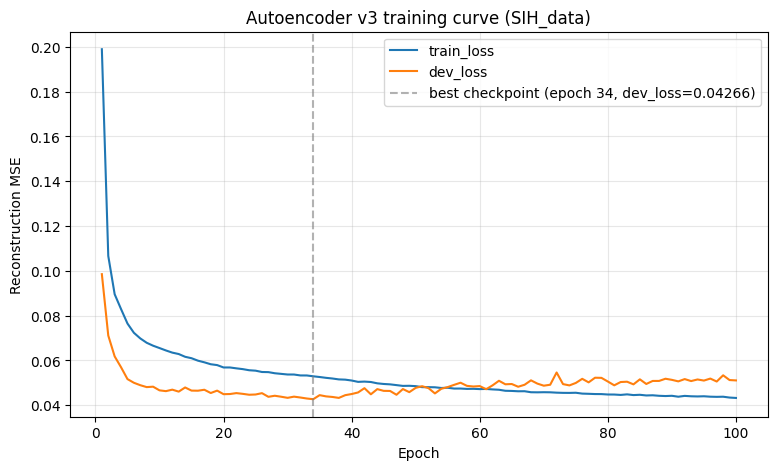

In [13]:
import re
import matplotlib.pyplot as plt

# paste the full Cell 10 output between the triple quotes
log_text = """
Epoch   1: train_loss=0.19896  dev_loss=0.09851
Epoch   2: train_loss=0.10665  dev_loss=0.07110
Epoch   3: train_loss=0.08954  dev_loss=0.06178
Epoch   4: train_loss=0.08289  dev_loss=0.05692
Epoch   5: train_loss=0.07646  dev_loss=0.05165
Epoch   6: train_loss=0.07233  dev_loss=0.05001
Epoch   7: train_loss=0.06981  dev_loss=0.04892
Epoch   8: train_loss=0.06787  dev_loss=0.04807
Epoch   9: train_loss=0.06656  dev_loss=0.04826
Epoch  10: train_loss=0.06551  dev_loss=0.04662
Epoch  11: train_loss=0.06444  dev_loss=0.04627
Epoch  12: train_loss=0.06347  dev_loss=0.04693
Epoch  13: train_loss=0.06284  dev_loss=0.04605
Epoch  14: train_loss=0.06161  dev_loss=0.04791
Epoch  15: train_loss=0.06097  dev_loss=0.04651
Epoch  16: train_loss=0.05988  dev_loss=0.04646
Epoch  17: train_loss=0.05914  dev_loss=0.04689
Epoch  18: train_loss=0.05828  dev_loss=0.04543
Epoch  19: train_loss=0.05790  dev_loss=0.04650
Epoch  20: train_loss=0.05684  dev_loss=0.04491
Epoch  21: train_loss=0.05684  dev_loss=0.04498
Epoch  22: train_loss=0.05645  dev_loss=0.04539
Epoch  23: train_loss=0.05610  dev_loss=0.04506
Epoch  24: train_loss=0.05560  dev_loss=0.04466
Epoch  25: train_loss=0.05541  dev_loss=0.04477
Epoch  26: train_loss=0.05482  dev_loss=0.04537
Epoch  27: train_loss=0.05476  dev_loss=0.04374
Epoch  28: train_loss=0.05426  dev_loss=0.04421
Epoch  29: train_loss=0.05398  dev_loss=0.04377
Epoch  30: train_loss=0.05370  dev_loss=0.04328
Epoch  31: train_loss=0.05369  dev_loss=0.04381
Epoch  32: train_loss=0.05328  dev_loss=0.04342
Epoch  33: train_loss=0.05327  dev_loss=0.04298
Epoch  34: train_loss=0.05290  dev_loss=0.04266
Epoch  35: train_loss=0.05258  dev_loss=0.04448
Epoch  36: train_loss=0.05221  dev_loss=0.04393
Epoch  37: train_loss=0.05191  dev_loss=0.04367
Epoch  38: train_loss=0.05151  dev_loss=0.04325
Epoch  39: train_loss=0.05140  dev_loss=0.04447
Epoch  40: train_loss=0.05101  dev_loss=0.04498
Epoch  41: train_loss=0.05041  dev_loss=0.04568
Epoch  42: train_loss=0.05053  dev_loss=0.04759
Epoch  43: train_loss=0.05035  dev_loss=0.04486
Epoch  44: train_loss=0.04976  dev_loss=0.04717
Epoch  45: train_loss=0.04947  dev_loss=0.04640
Epoch  46: train_loss=0.04930  dev_loss=0.04635
Epoch  47: train_loss=0.04896  dev_loss=0.04465
Epoch  48: train_loss=0.04861  dev_loss=0.04720
Epoch  49: train_loss=0.04866  dev_loss=0.04582
Epoch  50: train_loss=0.04850  dev_loss=0.04773
Epoch  51: train_loss=0.04805  dev_loss=0.04848
Epoch  52: train_loss=0.04805  dev_loss=0.04761
Epoch  53: train_loss=0.04799  dev_loss=0.04525
Epoch  54: train_loss=0.04768  dev_loss=0.04733
Epoch  55: train_loss=0.04778  dev_loss=0.04808
Epoch  56: train_loss=0.04742  dev_loss=0.04908
Epoch  57: train_loss=0.04743  dev_loss=0.05003
Epoch  58: train_loss=0.04727  dev_loss=0.04863
Epoch  59: train_loss=0.04731  dev_loss=0.04834
Epoch  60: train_loss=0.04718  dev_loss=0.04853
Epoch  61: train_loss=0.04725  dev_loss=0.04713
Epoch  62: train_loss=0.04704  dev_loss=0.04885
Epoch  63: train_loss=0.04689  dev_loss=0.05090
Epoch  64: train_loss=0.04643  dev_loss=0.04933
Epoch  65: train_loss=0.04636  dev_loss=0.04945
Epoch  66: train_loss=0.04621  dev_loss=0.04823
Epoch  67: train_loss=0.04623  dev_loss=0.04912
Epoch  68: train_loss=0.04578  dev_loss=0.05109
Epoch  69: train_loss=0.04574  dev_loss=0.04963
Epoch  70: train_loss=0.04579  dev_loss=0.04870
Epoch  71: train_loss=0.04575  dev_loss=0.04913
Epoch  72: train_loss=0.04559  dev_loss=0.05460
Epoch  73: train_loss=0.04550  dev_loss=0.04941
Epoch  74: train_loss=0.04548  dev_loss=0.04883
Epoch  75: train_loss=0.04555  dev_loss=0.04993
Epoch  76: train_loss=0.04517  dev_loss=0.05177
Epoch  77: train_loss=0.04508  dev_loss=0.05019
Epoch  78: train_loss=0.04497  dev_loss=0.05226
Epoch  79: train_loss=0.04495  dev_loss=0.05220
Epoch  80: train_loss=0.04477  dev_loss=0.05056
Epoch  81: train_loss=0.04475  dev_loss=0.04887
Epoch  82: train_loss=0.04458  dev_loss=0.05034
Epoch  83: train_loss=0.04483  dev_loss=0.05048
Epoch  84: train_loss=0.04451  dev_loss=0.04930
Epoch  85: train_loss=0.04464  dev_loss=0.05154
Epoch  86: train_loss=0.04434  dev_loss=0.04947
Epoch  87: train_loss=0.04442  dev_loss=0.05082
Epoch  88: train_loss=0.04419  dev_loss=0.05083
Epoch  89: train_loss=0.04408  dev_loss=0.05181
Epoch  90: train_loss=0.04419  dev_loss=0.05131
Epoch  91: train_loss=0.04378  dev_loss=0.05063
Epoch  92: train_loss=0.04415  dev_loss=0.05165
Epoch  93: train_loss=0.04397  dev_loss=0.05077
Epoch  94: train_loss=0.04390  dev_loss=0.05148
Epoch  95: train_loss=0.04398  dev_loss=0.05099
Epoch  96: train_loss=0.04379  dev_loss=0.05188
Epoch  97: train_loss=0.04372  dev_loss=0.05056
Epoch  98: train_loss=0.04378  dev_loss=0.05334
Epoch  99: train_loss=0.04340  dev_loss=0.05122
Epoch 100: train_loss=0.04323  dev_loss=0.05106
"""

pattern = re.compile(r"Epoch\s+(\d+):\s+train_loss=([\d.]+)\s+dev_loss=([\d.]+)")
epochs, train_losses, dev_losses = [], [], []
for m in pattern.finditer(log_text):
    epochs.append(int(m.group(1)))
    train_losses.append(float(m.group(2)))
    dev_losses.append(float(m.group(3)))

print(f"Parsed {len(epochs)} epochs")

plt.figure(figsize=(9, 5))
plt.plot(epochs, train_losses, label="train_loss")
plt.plot(epochs, dev_losses, label="dev_loss")

# mark the best checkpoint (lowest dev_loss) -- that's the one actually saved
best_idx = dev_losses.index(min(dev_losses))
plt.axvline(epochs[best_idx], color="gray", linestyle="--", alpha=0.6,
            label=f"best checkpoint (epoch {epochs[best_idx]}, dev_loss={dev_losses[best_idx]:.5f})")

plt.xlabel("Epoch")
plt.ylabel("Reconstruction MSE")
plt.title("Autoencoder v3 training curve (SIH_data)")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('/content/ml/artifacts/autoencoder/v3/training_curve.png', dpi=150, bbox_inches='tight')
plt.show()

Model loaded. Threshold = 0.18367
Faulted example: UNIT-alternatordegradation-0100_M005 (alternatordegradation)
Healthy example: UNIT-healthy-0001_M005

--- Faulted run sample ---
    t engine_state  is_healthy  ae_recon_error  ae_anomaly_flag
0   3         IDLE       False       91.482872             True
1   4         IDLE       False      126.106804             True
2   5         IDLE       False      136.679794             True
3   6         IDLE       False      139.350235             True
4   7         IDLE       False      140.832291             True
5   8         IDLE       False      140.990875             True
6   9         IDLE       False      141.036316             True
7  10         IDLE       False      141.048935             True
8  11         IDLE       False      141.052017             True
9  12         IDLE       False      141.052383             True

Anomaly flag rate: 100.0%

--- Healthy run sample ---
    t engine_state  is_healthy  ae_recon_error  ae_anomaly_fl

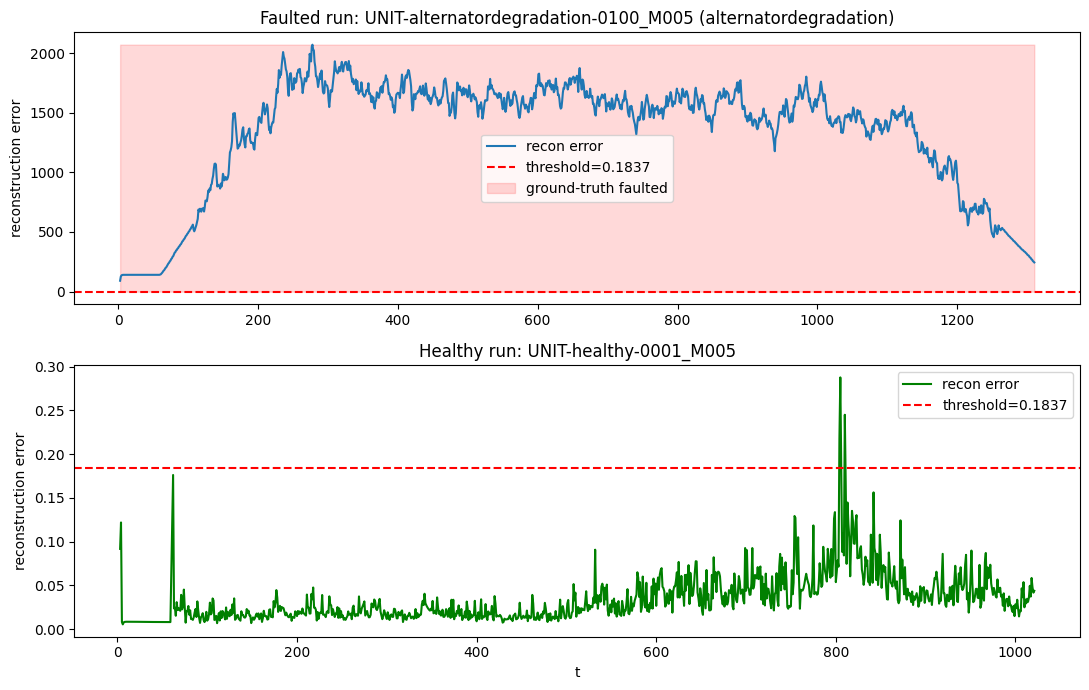

In [14]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from ml.training.autoencoder.train import (
    AE_CONDITION_FEATURES, TelemetryAutoencoder, _build_features,
    _load_run_groundtruth_health, _load_run_telemetry,
)

DATA_PATH = Path("data/processed/sih_data_v3")
AE_ARTIFACTS = Path("ml/artifacts/autoencoder/v3")
TWIN_ARTIFACTS = Path("ml/artifacts/digital_twin/v3")

# --- load model + scaler + threshold once ---
ae_meta = json.loads((AE_ARTIFACTS / "metadata.json").read_text())
scaler = json.loads((AE_ARTIFACTS / "scaler.json").read_text())
threshold = json.loads((AE_ARTIFACTS / "threshold.json").read_text())["threshold"]

feature_columns = ae_meta["feature_columns"]
residual_columns = ae_meta["residual_columns"]
scale_columns = scaler["columns"]
mean = np.array(scaler["mean"])
std = np.array(scaler["std"])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = TelemetryAutoencoder(input_dim=len(feature_columns), latent_dim=ae_meta["hyperparameters"]["latent_dim"])
model.load_state_dict(torch.load(AE_ARTIFACTS / "model.pt", map_location=device))
model.to(device).eval()

twin_meta = json.loads((TWIN_ARTIFACTS / "metadata.json").read_text())
telemetry_cols = sorted(set(
    twin_meta["target_channels"] + twin_meta["condition_features"] + AE_CONDITION_FEATURES + ["engine_state", "t"]
))

print(f"Model loaded. Threshold = {threshold:.5f}")


def run_one(run_id: str, split: str):
    """Run a single run_id through the v3 autoencoder and return a per-row dataframe."""
    telemetry = _load_run_telemetry(DATA_PATH, split, run_id, telemetry_cols)
    labels = _load_run_groundtruth_health(DATA_PATH, split, run_id)
    merged = telemetry.merge(labels, on="t", how="inner", validate="one_to_one")

    features, keep_mask = _build_features(merged, TWIN_ARTIFACTS, residual_columns)
    if features.empty:
        print(f"No usable rows for {run_id} (all gated-out states or NaN residuals)")
        return None

    scaled = features.copy()
    scaled[scale_columns] = (features[scale_columns].values - mean) / std
    x = torch.tensor(scaled[feature_columns].values.astype(np.float32)).to(device)

    with torch.no_grad():
        recon = model(x)
        recon_error = ((recon - x) ** 2).mean(dim=1).cpu().numpy()

    kept = merged.loc[keep_mask.values].reset_index(drop=True)
    out = pd.DataFrame({
        "t": kept["t"].values,
        "engine_state": kept["engine_state"].values,
        "is_healthy": kept["is_healthy"].values,
        "ae_recon_error": recon_error,
        "ae_anomaly_flag": recon_error > threshold,
    })
    return out


# --- pick an example run: one faulted, one healthy, for comparison ---
meta_dir = DATA_PATH / "meta"
faulted_run, healthy_run = None, None
for meta_file in sorted(meta_dir.glob("*.meta.json")):
    meta = json.loads(meta_file.read_text())
    if meta["split"] != "validation":
        continue
    if faulted_run is None and meta["fault_class"] != "healthy":
        faulted_run = meta["run_id"]
        faulted_class = meta["fault_class"]
    if healthy_run is None and meta["fault_class"] == "healthy":
        healthy_run = meta["run_id"]
    if faulted_run and healthy_run:
        break

print(f"Faulted example: {faulted_run} ({faulted_class})")
print(f"Healthy example: {healthy_run}")

result_faulted = run_one(faulted_run, "validation")
result_healthy = run_one(healthy_run, "validation")

print("\n--- Faulted run sample ---")
print(result_faulted.head(10))
print(f"\nAnomaly flag rate: {result_faulted['ae_anomaly_flag'].mean():.1%}")

print("\n--- Healthy run sample ---")
print(result_healthy.head(10))
print(f"\nAnomaly flag rate: {result_healthy['ae_anomaly_flag'].mean():.1%}")

# --- plot both side by side ---
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=False)

axes[0].plot(result_faulted["t"], result_faulted["ae_recon_error"], label="recon error")
axes[0].axhline(threshold, color="red", linestyle="--", label=f"threshold={threshold:.4f}")
axes[0].fill_between(result_faulted["t"], 0, result_faulted["ae_recon_error"].max(),
                      where=~result_faulted["is_healthy"], alpha=0.15, color="red", label="ground-truth faulted")
axes[0].set_title(f"Faulted run: {faulted_run} ({faulted_class})")
axes[0].set_ylabel("reconstruction error")
axes[0].legend()

axes[1].plot(result_healthy["t"], result_healthy["ae_recon_error"], label="recon error", color="green")
axes[1].axhline(threshold, color="red", linestyle="--", label=f"threshold={threshold:.4f}")
axes[1].set_title(f"Healthy run: {healthy_run}")
axes[1].set_xlabel("t")
axes[1].set_ylabel("reconstruction error")
axes[1].legend()

plt.tight_layout()
plt.savefig(AE_ARTIFACTS / "example_run_inspection.png", dpi=150, bbox_inches="tight")
plt.show()